# Titanic - Machine Learning from Disaster

#### Path settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import os

class Config:
    # 環境判定
    IS_KAGGLE = bool(os.getenv("KAGGLE_URL_BASE"))

    # ルート
    # Kaggleでは /kaggle/working、ローカルでは現在の作業ディレクトリ
    ROOT = Path("/kaggle/working") if IS_KAGGLE else Path.cwd()

    # データ（読み込み専用）
    DATA = Path("/kaggle/input/competitions/titanic") if IS_KAGGLE else ROOT / "data" / "raw"

    # 出力
    OUTPUT = ROOT / "output" if not IS_KAGGLE else ROOT

    # DBパス
    # Kaggleでは /kaggle/working/titanic.duckdb になります
    DB = ROOT / "titanic.duckdb" if IS_KAGGLE else ROOT / "data" / "db" / "titanic.duckdb"

    # print(ROOT)
    # print(DATA)
    # print(OUTPUT)
    # print(DB)

    @classmethod
    def setup(cls):
        """ディレクトリの作成を一括で行うメソッド"""
        # OUTPUTディレクトリの作成（Kaggleでは ROOT なので作成不要だが、ローカルでは必要）
        cls.OUTPUT.mkdir(parents=True, exist_ok=True)
        
        # DBファイルの親ディレクトリ（data/dbなど）を作成
        cls.DB.parent.mkdir(parents=True, exist_ok=True)

# 実行
Config.setup()

In [3]:
import duckdb
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

#### CREATE TABLE (train and test)

In [4]:
# DuckDBに接続
conn = duckdb.connect(Config.DB)

def create_train():
    # trainデータをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE raw_train_tbl AS
        SELECT *
        FROM read_csv_auto('{Config.DATA}/train.csv')
    """)

def create_test():
    # testデータをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE raw_test_tbl AS
        SELECT *
        FROM read_csv_auto('{Config.DATA}/test.csv')
    """)

create_train()
create_test()

In [5]:
raw_train_pl = conn.table("raw_train_tbl").pl()
raw_test_pl = conn.table("raw_test_tbl").pl()

# まずはデータの行数と列数を確認
print(f"train: {raw_train_pl.shape}")
print(f"test: {raw_test_pl.shape}")

# 表を並べて確認する
display(raw_train_pl.head(), raw_test_pl.head())

train: (891, 12)
test: (418, 11)


PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,i64,str,str,f64,i64,i64,str,f64,str,str
1,0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
2,1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
3,1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
4,1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
5,0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S"""


PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,str,str,f64,i64,i64,str,f64,str,str
892,3,"""Kelly, Mr. James""","""male""",34.5,0,0,"""330911""",7.8292,null,"""Q"""
893,3,"""Wilkes, Mrs. James (Ellen Need…","""female""",47.0,1,0,"""363272""",7.0,null,"""S"""
894,2,"""Myles, Mr. Thomas Francis""","""male""",62.0,0,0,"""240276""",9.6875,null,"""Q"""
895,3,"""Wirz, Mr. Albert""","""male""",27.0,0,0,"""315154""",8.6625,null,"""S"""
896,3,"""Hirvonen, Mrs. Alexander (Helg…","""female""",22.0,1,1,"""3101298""",12.2875,null,"""S"""


#### CREATE join data

In [6]:
def create_join_data():
    
    # 結合データをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE raw_join_data_tbl AS
        ( SELECT
            PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
        FROM raw_train_tbl
        UNION ALL
        SELECT
            PassengerId,NULL as Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
        FROM raw_test_tbl
        )
        """)

create_join_data()

In [7]:
raw_join_data_pl = conn.table("raw_join_data_tbl").pl()

# 結合データのサマリを確認
print(raw_join_data_pl.describe())

shape: (9, 13)
┌────────────┬─────────────┬──────────┬──────────┬─────────────────────────────┬────────┬───────────┬──────────┬──────────┬───────────┬───────────┬───────┬──────────┐
│ statistic  ┆ PassengerId ┆ Survived ┆ Pclass   ┆ Name                        ┆ Sex    ┆ Age       ┆ SibSp    ┆ Parch    ┆ Ticket    ┆ Fare      ┆ Cabin ┆ Embarked │
│ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---                         ┆ ---    ┆ ---       ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---   ┆ ---      │
│ str        ┆ f64         ┆ f64      ┆ f64      ┆ str                         ┆ str    ┆ f64       ┆ f64      ┆ f64      ┆ str       ┆ f64       ┆ str   ┆ str      │
╞════════════╪═════════════╪══════════╪══════════╪═════════════════════════════╪════════╪═══════════╪══════════╪══════════╪═══════════╪═══════════╪═══════╪══════════╡
│ count      ┆ 1309.0      ┆ 891.0    ┆ 1309.0   ┆ 1309                        ┆ 1309   ┆ 1046.0    ┆ 1309.0   ┆ 1309.0   ┆ 1309      ┆ 1308.0    ┆ 29

- 欠損値　→　年齢、値段、客室、港に欠損値あり。特に客室情報は抜けが多い <br>
　　→　客室情報は抜けが多いから落としてしまった方がいいかも <br>
- 年齢は普通に平均で埋めちゃったらまずそう。なにか他の値を参考にできないか <br>
　　→　MrとかMrsとかついてるので、その平均で埋めれるのでは？もしくは平均と中央値があんまり離れてるならどちらを採用するかも考えたほうがいいかも <br>
- 映画で見たら、お金持ちから助かったっぽいイメージ。チケットの値段からお金持ちかどうかわかるかも？ <br>
　　→　相関を見ておく。ところで、チケット代のminが0円…タダってこと？なんで？従業員？？？ <br>
- 出向した港は、0.15%の欠損だけど、なんとなく生存率には関係ないのでは？ <br>
　　→　相関を見ておく <br>

In [8]:
# 年齢の欠損値埋めるために、MrとかMrsとか抜いてる。ついでにその平均値,
# 中央値も切り捨てで表示。
print(
conn.query("""
SELECT
    trim(split_part(split_part(Name, ',', 2), '.', 1)) AS title,
    ROUND(AVG(Age),1) as avg_age,
    median(Age) as med_age,
    count(CASE WHEN Survived is not null and Age is null then PassengerId end) as train_null_count,
    count(CASE WHEN Survived is null and Age is null then PassengerId end) as test_mnull_count
FROM raw_join_data_tbl
GROUP BY trim(split_part(split_part(Name, ',', 2), '.', 1))
""").pl()
)

shape: (18, 5)
┌──────────────┬─────────┬─────────┬──────────────────┬──────────────────┐
│ title        ┆ avg_age ┆ med_age ┆ train_null_count ┆ test_mnull_count │
│ ---          ┆ ---     ┆ ---     ┆ ---              ┆ ---              │
│ str          ┆ f64     ┆ f64     ┆ i64              ┆ i64              │
╞══════════════╪═════════╪═════════╪══════════════════╪══════════════════╡
│ Don          ┆ 40.0    ┆ 40.0    ┆ 0                ┆ 0                │
│ Rev          ┆ 41.3    ┆ 41.5    ┆ 0                ┆ 0                │
│ Capt         ┆ 70.0    ┆ 70.0    ┆ 0                ┆ 0                │
│ Mr           ┆ 32.3    ┆ 29.0    ┆ 119              ┆ 57               │
│ Dr           ┆ 43.6    ┆ 49.0    ┆ 1                ┆ 0                │
│ Mlle         ┆ 24.0    ┆ 24.0    ┆ 0                ┆ 0                │
│ Ms           ┆ 28.0    ┆ 28.0    ┆ 0                ┆ 1                │
│ Sir          ┆ 49.0    ┆ 49.0    ┆ 0                ┆ 0                │
│ Jonkheer

In [9]:
# EmbarkedのNULLチェック
conn.sql("""
SELECT
    Embarked,
    count(PassengerId)
FROM raw_join_data_tbl
GROUP BY Embarked
""").show()

┌──────────┬────────────────────┐
│ Embarked │ count(PassengerId) │
│ varchar  │       int64        │
├──────────┼────────────────────┤
│ NULL     │                  2 │
│ C        │                270 │
│ Q        │                123 │
│ S        │                914 │
└──────────┴────────────────────┘



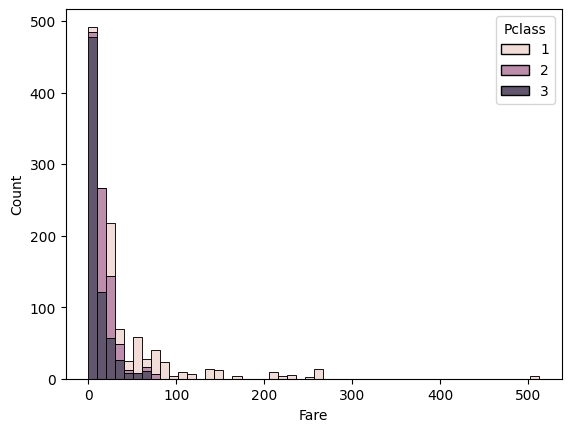

In [10]:
# チケット価格ごとのPclassを確認

sns.histplot(
    raw_join_data_pl.to_pandas(),
    x="Fare",
    hue="Pclass",
    bins=50,
    multiple="stack" #人数で確認
)

plt.show()

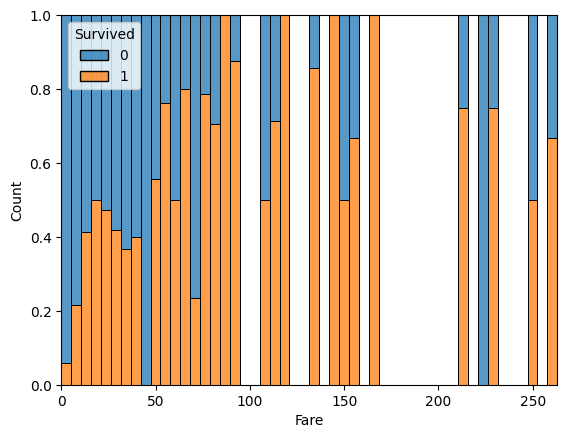

In [11]:
# チケット価格ごとの生存を確認(500以上は除外値とする)

train_check_pd = raw_join_data_pl.filter(pl.col("Survived").is_not_null()).to_pandas()

sns.histplot(
    data=train_check_pd[train_check_pd["Fare"] < 300],
    x="Fare",
    hue="Survived",
    bins=50,
    multiple="fill"
)

plt.show()

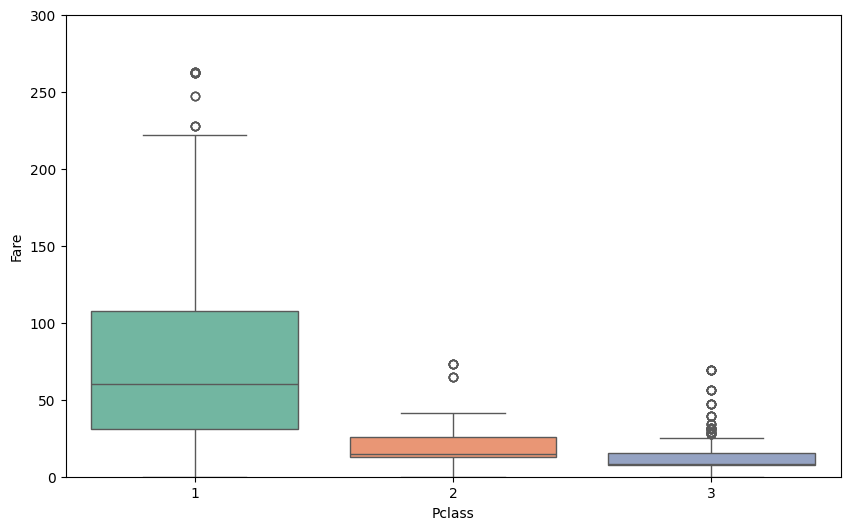

In [12]:
# Pclassごとのチケット代、箱ひげで確認

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=raw_join_data_pl,
    x="Pclass",
    y="Fare",
    palette="Set2"
)
plt.ylim(0, 300) # 300以上は除外
plt.show()

In [13]:
# 値段NULLを埋めるためにテーブル確認する

print(conn.sql("""
SELECT
    *
FROM raw_join_data_tbl
WHERE Fare IS NULL
"""))

# Pclass 3 でNULLなので
print(conn.sql("""
SELECT
    MIN(Fare),
    MAX(Fare),
    avg(Fare),
    median(Fare)
FROM raw_join_data_tbl
WHERE Pclass = 3 AND Fare <> 0
"""))

┌─────────────┬──────────┬────────┬────────────────────┬─────────┬────────┬───────┬───────┬─────────┬────────┬─────────┬──────────┐
│ PassengerId │ Survived │ Pclass │        Name        │   Sex   │  Age   │ SibSp │ Parch │ Ticket  │  Fare  │  Cabin  │ Embarked │
│    int64    │  int64   │ int64  │      varchar       │ varchar │ double │ int64 │ int64 │ varchar │ double │ varchar │ varchar  │
├─────────────┼──────────┼────────┼────────────────────┼─────────┼────────┼───────┼───────┼─────────┼────────┼─────────┼──────────┤
│        1044 │     NULL │      3 │ Storey, Mr. Thomas │ male    │   60.5 │     0 │     0 │ 3701    │   NULL │ NULL    │ S        │
└─────────────┴──────────┴────────┴────────────────────┴─────────┴────────┴───────┴───────┴─────────┴────────┴─────────┴──────────┘

┌───────────┬───────────┬────────────────────┬──────────────┐
│ min(Fare) │ max(Fare) │     avg(Fare)      │ median(Fare) │
│  double   │  double   │       double       │    double    │
├───────────┼────────

In [14]:
# 性別を1/0にする　"male"=1　"female"=0
# 年齢はintにする
# Embarked ワンホットエンコーディング(NULLは一番多いSで埋める)
# Cabin　除外
# 料金はPclassの中央値で補完

conn.execute("""
CREATE OR REPLACE TABLE feat_full_data_tbl AS
WITH title_master AS (
    SELECT 
        trim(split_part(split_part(Name, ',', 2), '.', 1)) AS title_name,
        median(Age) as med_age
    FROM raw_join_data_tbl
    GROUP BY 1
)
SELECT 
    J.PassengerId,
    J.Survived,
    J.Pclass,
    J.Name,
    T.title_name AS title,
    CASE WHEN J.Sex = 'male' THEN 1 ELSE 0 END AS Sex,
    CAST(COALESCE(J.Age, T.med_age) AS INT) AS Age,
    J.SibSp,
    J.Parch,
    J.Ticket,
    CAST(COALESCE(J.Fare, 8) AS INT) AS Fare,
    J.SibSp + J.Parch + 1 AS family_size,
    CASE WHEN J.Embarked = 'C' THEN 1 ELSE 0 END AS embarked_C,
    CASE WHEN J.Embarked = 'Q' THEN 1 ELSE 0 END AS embarked_Q,
    CASE WHEN J.Embarked = 'S' OR J.Embarked IS NULL THEN 1 ELSE 0 END AS embarked_S
FROM 
    raw_join_data_tbl AS J
LEFT JOIN 
    title_master AS T 
    ON trim(split_part(split_part(J.Name, ',', 2), '.', 1)) = T.title_name
""")

In [15]:
feat_full_data_tbl_pl = conn.table("feat_full_data_tbl").pl()

# 結合データのサマリを確認（NULL埋まったか）
print(feat_full_data_tbl_pl.describe())

shape: (9, 16)
┌────────────┬─────────────┬──────────┬──────────┬────────────────┬──────────┬──────────┬───────────┬──────────┬──────────┬───────────┬───────────┬─────────────┬────────────┬────────────┬────────────┐
│ statistic  ┆ PassengerId ┆ Survived ┆ Pclass   ┆ Name           ┆ title    ┆ Sex      ┆ Age       ┆ SibSp    ┆ Parch    ┆ Ticket    ┆ Fare      ┆ family_size ┆ embarked_C ┆ embarked_Q ┆ embarked_S │
│ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---            ┆ ---      ┆ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│ str        ┆ f64         ┆ f64      ┆ f64      ┆ str            ┆ str      ┆ f64      ┆ f64       ┆ f64      ┆ f64      ┆ str       ┆ f64       ┆ f64         ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪═════════════╪══════════╪══════════╪════════════════╪══════════╪══════════╪═══════════╪══════════╪══════════╪═══════════╪═══════════╪═════════════╪════════════╪═══════

In [16]:
# 相関を見ておく

print(
    conn.sql("SELECT * FROM feat_full_data_tbl WHERE Survived IS NOT NULL").pl()
      .select(
        pl.corr("Sex", "Survived"),
        pl.corr("Age", "Survived"),
        
        pl.corr("Pclass", "Survived"),
        pl.corr("Fare", "Survived"),


        pl.corr("embarked_C", "Survived"),
        pl.corr("embarked_Q", "Survived"),
        pl.corr("embarked_S", "Survived"),

        pl.corr("SibSp", "Survived"),
        pl.corr("Parch", "Survived"),
        pl.corr("family_size", "Survived")
    )
)

shape: (1, 10)
┌───────────┬───────────┬───────────┬──────────┬────────────┬────────────┬────────────┬───────────┬──────────┬─────────────┐
│ Sex       ┆ Age       ┆ Pclass    ┆ Fare     ┆ embarked_C ┆ embarked_Q ┆ embarked_S ┆ SibSp     ┆ Parch    ┆ family_size │
│ ---       ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---      ┆ ---         │
│ f64       ┆ f64       ┆ f64       ┆ f64      ┆ f64        ┆ f64        ┆ f64        ┆ f64       ┆ f64      ┆ f64         │
╞═══════════╪═══════════╪═══════════╪══════════╪════════════╪════════════╪════════════╪═══════════╪══════════╪═════════════╡
│ -0.543351 ┆ -0.070467 ┆ -0.338481 ┆ 0.257088 ┆ 0.16824    ┆ 0.00365    ┆ -0.149683  ┆ -0.035322 ┆ 0.081629 ┆ 0.016639    │
└───────────┴───────────┴───────────┴──────────┴────────────┴────────────┴────────────┴───────────┴──────────┴─────────────┘


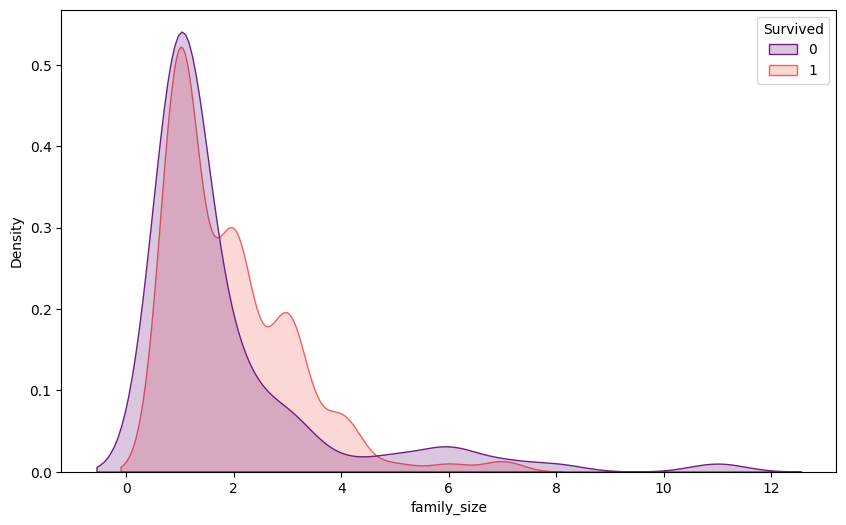

In [17]:
# family_sizeほんとにあんまり相関ない？

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=conn.sql(
        "SELECT * FROM feat_full_data_tbl WHERE Survived IS NOT NULL").pl(),
    x="family_size", hue="Survived", fill=True, common_norm=False, palette="magma")
plt.show()

In [18]:
# やっぱ関係ありそうな気がするので、3グループに分ける

conn.execute("""
UPDATE feat_full_data_tbl
    SET family_size = CASE WHEN family_size = 1 THEN 1
                        WHEN family_size BETWEEN 2 AND 7 THEN 2
                        ELSE 3 END
    """)

# 相関を見ておく
print(
    conn.sql("SELECT * FROM feat_full_data_tbl WHERE Survived IS NOT NULL").pl()
    .select(
        pl.corr("family_size", "Survived")
    )
)

shape: (1, 1)
┌─────────────┐
│ family_size │
│ ---         │
│ f64         │
╞═════════════╡
│ 0.168913    │
└─────────────┘


In [19]:
# 特徴量確定後のDataFrameを抽出

# 全データ（加工済み）をロード
processed_pl = conn.sql("""
                        SELECT 
                            PassengerId,
                            Survived,
                            Pclass,
                            Sex,
                            Age,
                            Fare,
                            family_size
                        FROM feat_full_data_tbl
                        """).pl()

# 1. 学習用データ (Survived がある行)
train_df = processed_pl.filter(pl.col("Survived").is_not_null())

# 2. 提出用データ (Survived が NULL の行)
test_df = processed_pl.filter(pl.col("Survived").is_null())

# まずはデータの行数と列数を確認
print(f"train: {train_df.shape}")
print(f"test: {test_df.shape}")

# 表を並べて確認する
display(train_df.head(), test_df.head())

train: (891, 7)
test: (418, 7)


PassengerId,Survived,Pclass,Sex,Age,Fare,family_size
i64,i64,i64,i32,i32,i32,i64
1,0,3,1,22,7,2
2,1,1,0,38,71,2
3,1,3,0,26,8,1
4,1,1,0,35,53,2
5,0,3,1,35,8,1


PassengerId,Survived,Pclass,Sex,Age,Fare,family_size
i64,i64,i64,i32,i32,i32,i64
892,null,3,1,34,8,1
893,null,3,0,47,7,2
894,null,2,1,62,10,1
895,null,3,1,27,9,1
896,null,3,0,22,12,2


#### Model

In [20]:
from sklearn.model_selection import train_test_split

# 特徴量 (X) と 正解 (y) に分ける
# 最後に提出するものではなく、ローカルで精度を確認するため、trainを2つに分けて検証

X = train_df.drop(["PassengerId","Survived"]).to_pandas().copy()
y = train_df["Survived"].to_pandas().copy()

# 分割実行
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"学習用: {X_train.shape}, 検証用: {X_valid.shape}")

学習用: (712, 5), 検証用: (179, 5)


#### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# 1. モデルのインスタンス作成（まずはデフォルト設定でOK）
# 分類問題（生存か死亡か）を解くためのLightGBM専用ツール
model = lgb.LGBMClassifier(random_state=42)

# 2. 学習（訓練データ X_train, y_train を投入）
model.fit(X_train, y_train)

# 3. 検証（模擬試験 X_valid を解かせてみる）
y_pred = model.predict(X_valid)

# 4. 答え合わせ（精度を確認）
accuracy = accuracy_score(y_valid, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

In [22]:
# どの変数が予測に役立ったかを確認

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

       feature  importance
2          Age        1232
3         Fare         987
0       Pclass         134
1          Sex         118
4  family_size          76


#### Submit

In [23]:
# 1. 提出用データ (SurvivedがNULLだった行) から特徴量を抽出
# ※ X_train と全く同じカラム順・型にする
X_test = test_df.drop(["PassengerId","Survived"]).to_pandas().copy()

# 2. 予測の実行 (0 or 1 が返る)
test_preds = model.predict(X_test)

# 3. 提出用 DataFrame の作成
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_preds
})

# 4. CSVとして保存 (Indexは不要)
submission.to_csv(Config.OUTPUT / "submission.csv", index=False)
print("提出用CSV保存 完了")

提出用CSV保存 完了


In [24]:
conn.close()